# 07 · Tarea 4 — Incertidumbre: clase + varianza

**Objetivo.** A partir de la **topologia con dropout que fija el tuner** (notebook 06; palanca compartida **D-3.2 ↔ D-4.1**), producir sobre `test` una prediccion que devuelva **clase + varianza** mediante **MC-Dropout** (D-4.1): se hacen **T pasadas** dejando el dropout **activo en inferencia** (`model(X_test, training=True)`); la **media** de las `T` probabilidades fija la **clase** (umbral `tau`, **D-4.4**) y la **`Var[p]`** entre pasadas mide la **incertidumbre epistemica**. El numero de pasadas **T** se decide en **D-4.2** comprobando que la varianza se estabiliza. Con eso se grafica la **distribucion de la varianza "buen pagador" vs "mal pagador"** (entregable **E3**) y se **cruza la varianza con `N_EXT_MISSING`** (**D-4.3**) para responder la pregunta del taller: *¿hay mas duda donde faltan las fuentes externas?* Como **entrega base fiel al profe** se anade el **segundo modelo del error** (`|p-y|`), lo minimo que pide entregar ([T4] §3.2, `docs/teoria/04-incertidumbre.md`).

**Dos incertidumbres, una protagonista.** La teoría (§1.3) separa la incertidumbre **aleatoria** (ruido irreducible del mundo; su proxy en clasificación es `p(1−p)`) de la **epistémica** (duda del modelo por falta de datos, aquí `Var[p]`). Este notebook produce como salida principal la **epistémica** vía MC-Dropout —porque la pregunta de `EXT_SOURCE` es *"¿dónde es ciego el modelo?"*, epistémica— y deja la aleatoria y su descomposición como **extensión** (D-4.5). Rigor sobre el origen de cada pieza: la distinción aleatoria/epistémica es **[Del material]**; leer `Var[p]` por MC-Dropout como epistémica en un **clasificador** es **[Propuesta razonada]** (teoría §2.5); el **2º modelo del error** (E4) es el mínimo **literal** que pide el profe ([T4] §3.2).

## Decisiones a tomar antes de empezar

> Fichas de `docs/DECISIONES.md` para esta tarea. **Estado real** copiado tal cual.
> Las decisiones en **Propuesta**/**Abierta** se **validan con el grupo ANTES de
> implementar**: este notebook asume la *Propuesta* por defecto, pero es revisable.

| Decision | Opciones | Estado |
|---|---|---|
| **D-4.1** · Metodo para la varianza | (a) 2o modelo del error / (b) **MC-Dropout** / (c) deep ensemble | Propuesta |
| **D-4.2** · No de pasadas/miembros T | 15 / 100 / **sug. 50-100** comprobando estabilidad | **Abierta** |
| **D-4.3** · Medir calidad de `EXT_SOURCE` | **`N_EXT_MISSING` (0-3) + flags `*_missing`** / flag binario / magnitud imputada | Propuesta |
| **D-4.4** · Umbral tau de clasificacion | 0,5 fijo / **ajustado por coste FN** / por percentil (desbalance 11,4:1 => tau<0,5) | **Abierta** |
| **D-4.5** · Descomposicion aleatoria/epistemica + calibracion | hacerlo / **dejar como extension** | Propuesta (extension) |

> **Nota.** **D-4.1 (MC-Dropout)** reutiliza el **dropout que fija el tuner** (06): es el
> cruce **D-3.2 <-> D-4.1**, no se introduce un dropout nuevo desacoplado. Las decisiones en
> **Propuesta**/**Abierta** se **validan con el grupo antes de implementar**.

In [1]:
# === Setup comun (notebooks de modelado 03-07) ===
import os
os.environ["KERAS_BACKEND"] = "tensorflow"   # backend unico para todo el grupo

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidad
RNG = 42
np.random.seed(RNG)
import random; random.seed(RNG)
try:
    import keras
    keras.utils.set_random_seed(RNG)
except Exception:
    pass

# Estilo heredado del EDA / preprocesado
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
COLOR_PAGA   = "#2c7fb8"   # TARGET=0  (paga)
COLOR_IMPAGA = "#d7301f"   # TARGET=1  (impaga)
COLOR_ACENTO = "#41ab5d"   # neutro

# Rutas estandar
PROC_DIR = Path("../data/processed")
FIG_DIR  = Path("../results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR  = Path("../results/tables");  TAB_DIR.mkdir(parents=True, exist_ok=True)

# --- Especifico Tarea 4 ---
import keras
import sys; sys.path.append("..")
try:
    from src import uncertainty
except Exception:
    uncertainty = None   # tolerante: el stub existe, pero por robustez no se exige
print("keras:", keras.__version__, "| uncertainty:", "OK" if uncertainty else "no disponible")

keras: 3.14.0 | uncertainty: OK


In [2]:
import json
from pathlib import Path
import pandas as pd

# --- Rutas y metadatos (fuente de verdad: metadata.json del preprocesado) ---
PROC_DIR   = Path("../data/processed")                       # relativo a notebooks/
META       = json.loads((PROC_DIR / "metadata.json").read_text(encoding="utf-8"))
FEATURES_X = META["columns"]["features_X"]   # 13 features, en orden
SENSIBLE   = META["columns"]["sensible"]     # "CODE_GENDER"  (s)
TARGET     = META["columns"]["target"]       # "TARGET"       (y)

def cargar_split(nombre):
    """Devuelve (X, y, s) para 'train' | 'val' | 'test'.
    X = DataFrame solo con las 13 features (SIN genero).
    y = Series TARGET (1=impaga, 0=paga).  s = Series CODE_GENDER (M=1/F=0).
    """
    df = pd.read_parquet(PROC_DIR / f"{nombre}.parquet")
    X = df[FEATURES_X]          # input del modelo: el genero NUNCA entra aqui
    y = df[TARGET]
    s = df[SENSIBLE]
    assert SENSIBLE not in X.columns, "FUGA: el genero esta dentro de X"
    return X, y, s

# Materializar los tres cortes
X_train, y_train, s_train = cargar_split("train")
X_val,   y_val,   s_val   = cargar_split("val")
X_test,  y_test,  s_test  = cargar_split("test")

# Resumen de control
print(f"{'split':<7}{'X (filas, cols)':>20}{'y':>12}{'s':>12}{'tasa_impago':>14}")
for n, (X, y, s) in {"train": (X_train, y_train, s_train),
                     "val":   (X_val,   y_val,   s_val),
                     "test":  (X_test,  y_test,  s_test)}.items():
    print(f"{n:<7}{str(tuple(X.shape)):>20}{str(tuple(y.shape)):>12}"
          f"{str(tuple(s.shape)):>12}{y.mean():>14.4%}")

# --- DESTACADO Tarea 4 (D-4.3): X_test YA trae la materia prima para cruzar varianza ---
# N_EXT_MISSING (0-3) + un flag *_missing por fuente externa estan dentro de X_test.
print("\n[D-4.3] Materia prima del cruce varianza <-> EXT_SOURCE (ya en X_test):")
print(X_test[["N_EXT_MISSING", "EXT_SOURCE_1_missing",
              "EXT_SOURCE_2_missing", "EXT_SOURCE_3_missing"]].describe())

split       X (filas, cols)           y           s   tasa_impago
train          (215254, 13)   (215254,)   (215254,)       8.0728%
val             (46126, 13)    (46126,)    (46126,)       8.0735%
test            (46127, 13)    (46127,)    (46127,)       8.0734%

[D-4.3] Materia prima del cruce varianza <-> EXT_SOURCE (ya en X_test):
       N_EXT_MISSING  EXT_SOURCE_1_missing  EXT_SOURCE_2_missing  \
count   46127.000000          46127.000000          46127.000000   
mean        0.765539              0.563249              0.002276   
std         0.651217              0.495989              0.047657   
min         0.000000              0.000000              0.000000   
25%         0.000000              0.000000              0.000000   
50%         1.000000              1.000000              0.000000   
75%         1.000000              1.000000              0.000000   
max         3.000000              1.000000              1.000000   

       EXT_SOURCE_3_missing  
count          46127

## Cargar / heredar el modelo con dropout del tuner (06)

Se **hereda la topologia + dropout** que **fija el notebook 06** (Keras Tuner): es el cruce
**D-3.2 <-> D-4.1**, el mismo dropout que MC-Dropout reutiliza en inferencia; si 06 aun no ha
exportado su artefacto, se documenta un *fallback* (MLP con `Dropout` local) para no bloquear.

In [3]:
# === Heredar el modelo de compromiso del NB06 (cruce D-3.2 <-> D-4.1) ===
import json as _j
import importlib
import warnings
from src import tuning; importlib.reload(tuning)
from sklearn.metrics import roc_auc_score

MODELS_DIR = PROC_DIR.parent / "models"
meta_c = _j.loads((MODELS_DIR / "06_modelo_compromiso.json").read_text(encoding="utf-8"))
HP = meta_c["hp_backbone"]; LAMBDA_STAR = float(meta_c["lambda_star"])
MEASURE_STAR = meta_c["measure_star"]; CW = tuple(meta_c["class_weights"])
N_FEATURES = X_test.shape[1]
print("Heredado del NB06:", {k: meta_c[k] for k in ["lambda_star", "measure_star", "fair_source"]})
print("Backbone:", HP)
assert float(HP["dropout_rate"]) > 0, "El backbone DEBE tener dropout (MC-Dropout, D-4.1)"

# Reconstruir EXACTAMENTE la arquitectura del NB06 y cargar sus pesos (la FAIR loss
# es un closure no serializable -> se reconstruye con build_fixed_model + load_weights).
modelo = tuning.build_fixed_model(HP, LAMBDA_STAR, n_features=meta_c["n_features"],
                                  include_custom_layer=meta_c["include_custom_layer"],
                                  class_weights=CW, measure=MEASURE_STAR)
# Warning benigno: al cargar pesos en un modelo recien compilado, Keras omite las
# variables del OPTIMIZER (no las del modelo) -> irrelevante para inferencia. Se silencia.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=".*Skipping variable loading for optimizer.*")
    modelo.load_weights(MODELS_DIR / "06_modelo_compromiso.weights.h5")

Xte = X_test.to_numpy("float32"); yte = y_test.to_numpy("int32")
p_det = modelo.predict(Xte, verbose=0).ravel()   # prediccion determinista (dropout OFF) de referencia
print(f"\nModelo heredado OK | AUC test (dropout OFF) = {roc_auc_score(yte, p_det):.4f}  "
      f"(coincide con el AUC del compromiso del NB06)")

Heredado del NB06: {'lambda_star': 5.0, 'measure_star': 'corr2', 'fair_source': 'src.fair_loss:corr2'}
Backbone: {'n_layers': 1, 'activation': 'relu', 'dropout_rate': 0.30000000000000004, 'lr': 0.007177664122743156, 'units_0': 64, 'units_1': 64}



Modelo heredado OK | AUC test (dropout OFF) = 0.7347  (coincide con el AUC del compromiso del NB06)


## MC-Dropout: T pasadas -> `Var[p]`

Se hacen **T pasadas** con `model(X_test, training=True)` (dropout activo en inferencia,
**D-4.1**): la **media** fija la clase (umbral `tau`) y la **varianza** entre pasadas es la
incertidumbre epistemica; **T** se decide en **D-4.2 (Abierta, sug. 50-100)**.

T=100 pasadas | Var[p] test: media=0.00148  mediana=0.00138  max=0.01736
AUC test con p_bar (consenso MC) = 0.7346  (~= dropout OFF, sin coste de precisión)


Figura estabilidad-T guardada


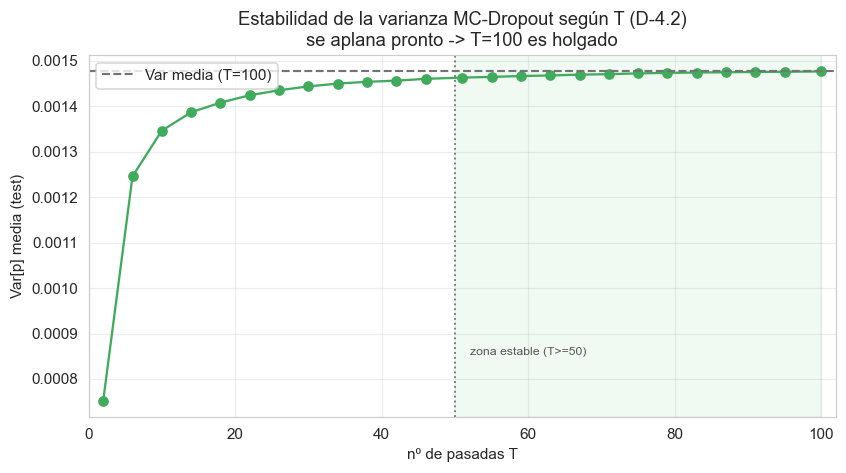

In [4]:
# === MC-Dropout: T pasadas -> Var[p]  (D-4.1, D-4.2) ===
from src import uncertainty; importlib.reload(uncertainty)
T_MAX = 100                                   # D-4.2: sug. 50-100; usamos 100 y comprobamos estabilidad
mc = uncertainty.mc_dropout_predict(modelo, Xte, T=T_MAX, tau=0.5, seed=RNG)
p_bar, var_p = mc["p_bar"], mc["var"]
print(f"T={T_MAX} pasadas | Var[p] test: media={var_p.mean():.5f}  mediana={np.median(var_p):.5f}  max={var_p.max():.5f}")
print(f"AUC test con p_bar (consenso MC) = {roc_auc_score(yte, p_bar):.4f}  (~= dropout OFF, sin coste de precisión)")

# D-4.2: la varianza media se estabiliza al crecer T? (no hace falta reentrenar)
ts, var_media = uncertainty.estabilidad_T(mc["preds"])
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.axvspan(50, T_MAX, color=COLOR_ACENTO, alpha=0.07)                 # zona estable
ax.plot(ts, var_media, "o-", color=COLOR_ACENTO)
ax.axvline(50, color="#737373", ls=":", lw=1.2)
ax.axhline(var_p.mean(), ls="--", color="#737373", lw=1.4, label=f"Var media (T={T_MAX})")
ax.annotate("zona estable (T>=50)", xy=(52, var_media.min() + 0.0001), fontsize=8, color="#555")
ax.set_xlabel("nº de pasadas T"); ax.set_ylabel("Var[p] media (test)")
ax.set_title("Estabilidad de la varianza MC-Dropout según T (D-4.2)\nse aplana pronto -> T=100 es holgado")
ax.set_xlim(0, T_MAX + 2); ax.legend(frameon=True); ax.grid(True, alpha=.35); fig.tight_layout()
fig.savefig(FIG_DIR / "07_incert__estabilidad_T.png", bbox_inches="tight", dpi=150)
print("Figura estabilidad-T guardada"); plt.show()

## Segundo modelo del error (entrega base)

Entrega **base fiel al profe** ([T4] §3.2): se crea la variable `error = |p - y|` en
train/val y se entrena un **segundo modelo** que la predice a partir de las mismas `X`.

2o modelo del error: val MAE=0.0412 | error medio predicho en test=0.4167


E4 guardada


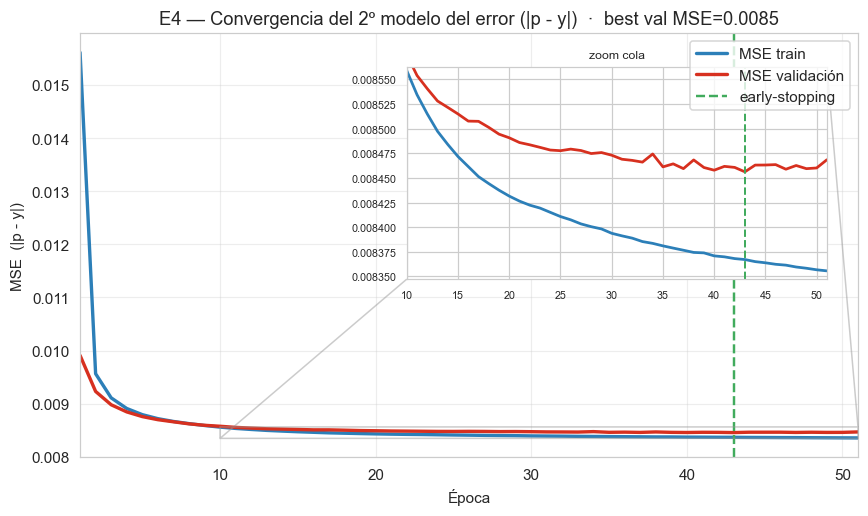

In [5]:
# === Segundo modelo del error |p-y| (entrega base fiel al profe, §3.2) -> E4 ===
# Patron de Valero: el modelo principal predice en train/val; se construye
# error=|p-y| y un 2o modelo lo predice desde las mismas X (incertidumbre heteroscedastica).
Xtr = X_train.to_numpy("float32"); ytr = y_train.to_numpy("float32")
Xvl = X_val.to_numpy("float32");   yvl = y_val.to_numpy("float32")
p_tr = modelo.predict(Xtr, verbose=0).ravel()   # dropout OFF (prediccion determinista)
p_vl = modelo.predict(Xvl, verbose=0).ravel()
err_tr = np.abs(p_tr - ytr); err_vl = np.abs(p_vl - yvl)

keras.utils.set_random_seed(RNG)
err_model = uncertainty.build_error_model(n_features=N_FEATURES)
stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
hist_err = err_model.fit(Xtr, err_tr, validation_data=(Xvl, err_vl),
                         epochs=60, batch_size=512, callbacks=[stop], verbose=0)
err_pred_test = err_model.predict(Xte, verbose=0).ravel()
print(f"2o modelo del error: val MAE={min(hist_err.history['val_mae']):.4f} | "
      f"error medio predicho en test={err_pred_test.mean():.4f}")

# E4: curva de loss del unico entrenamiento final del NB07 (el principal se hereda)
h = hist_err.history; ep = np.arange(1, len(h["loss"]) + 1)
best = int(np.argmin(h["val_loss"]))
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(ep, h["loss"], color=COLOR_PAGA, lw=2.2, label="MSE train")
ax.plot(ep, h["val_loss"], color=COLOR_IMPAGA, lw=2.2, label="MSE validación")
ax.axvline(best + 1, color=COLOR_ACENTO, ls="--", lw=1.6, label="early-stopping")
# inset con zoom a la cola: la accion esta en las primeras epocas; aqui se ve el (leve) overfit
if len(ep) > 12:
    axins = ax.inset_axes([0.42, 0.42, 0.54, 0.5])
    axins.plot(ep, h["loss"], color=COLOR_PAGA, lw=1.8)
    axins.plot(ep, h["val_loss"], color=COLOR_IMPAGA, lw=1.8)
    axins.axvline(best + 1, color=COLOR_ACENTO, ls="--", lw=1.3)
    axins.set_xlim(10, len(ep))
    cola = np.r_[h["loss"][10:], h["val_loss"][10:]]
    axins.set_ylim(cola.min() * 0.999, cola.max() * 1.001)
    axins.set_title("zoom cola", fontsize=8); axins.tick_params(labelsize=7)
    ax.indicate_inset_zoom(axins, edgecolor="#999")
ax.set_xlabel("Época"); ax.set_ylabel("MSE  (|p - y|)")
ax.set_title(f"E4 — Convergencia del 2º modelo del error (|p - y|)  ·  best val MSE={h['val_loss'][best]:.4f}")
ax.legend(frameon=True, loc="upper right"); ax.grid(True, alpha=.35); ax.set_xlim(1, len(ep)); fig.tight_layout()
fig.savefig(FIG_DIR / "07_incert__curva_loss.png", bbox_inches="tight", dpi=150)
print("E4 guardada"); plt.show()

## Distribucion de varianza: buen vs mal pagador (E3)

Entregable **E3**: histogramas/KDE de `Var[p]` por clase (**buen** vs **mal pagador**),
usando la paleta semantica (`COLOR_PAGA` vs `COLOR_IMPAGA`).

E3 guardada | por etiqueta: buen=0.00148 mal=0.00145 ratio=0.98x


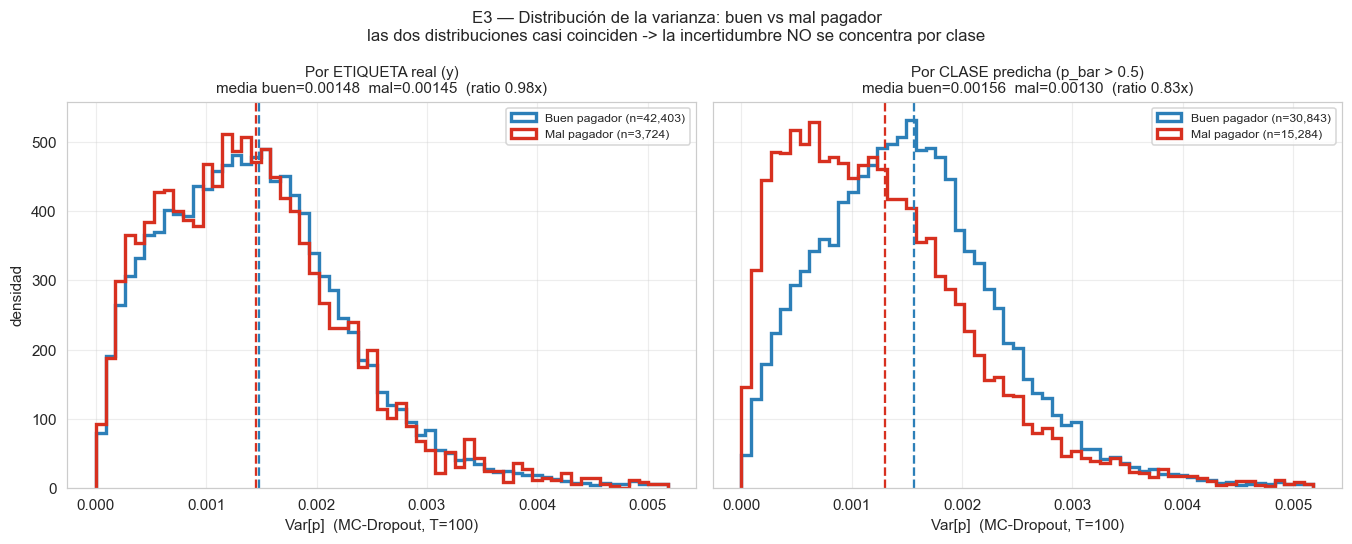

In [6]:
# === E3: distribucion de Var[p] buen vs mal pagador (por etiqueta real Y por clase predicha) ===
# El enunciado dice "usuarios CLASIFICADOS COMO" -> panel derecho por clase predicha (tau=0.5);
# panel izquierdo por etiqueta real (lectura habitual). Histogramas 'step' (no relleno) para que
# dos distribuciones casi iguales no se fundan en una mancha; medias con 5 decimales + ratio.
clase05 = (p_bar > 0.5).astype(int)
bins = np.linspace(0, np.quantile(var_p, 0.995), 60)

def _panel_e3(ax, grupo, etiqueta):
    buen_ = var_p[grupo == 0]; mal_ = var_p[grupo == 1]
    ax.hist(buen_, bins=bins, density=True, histtype="step", lw=2.2, color=COLOR_PAGA,
            label=f"Buen pagador (n={len(buen_):,})")
    ax.hist(mal_, bins=bins, density=True, histtype="step", lw=2.2, color=COLOR_IMPAGA,
            label=f"Mal pagador (n={len(mal_):,})")
    ax.axvline(buen_.mean(), color=COLOR_PAGA, ls="--", lw=1.5)
    ax.axvline(mal_.mean(), color=COLOR_IMPAGA, ls="--", lw=1.5)
    ax.set_title(f"{etiqueta}\nmedia buen={buen_.mean():.5f}  mal={mal_.mean():.5f}  "
                 f"(ratio {mal_.mean()/buen_.mean():.2f}x)", fontsize=10)
    ax.set_xlabel("Var[p]  (MC-Dropout, T=100)"); ax.grid(True, alpha=.35)
    ax.legend(frameon=True, fontsize=8)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 5.0), sharex=True, sharey=True)
_panel_e3(a1, yte, "Por ETIQUETA real (y)")
_panel_e3(a2, clase05, "Por CLASE predicha (p_bar > 0.5)")
a1.set_ylabel("densidad")
fig.suptitle("E3 — Distribución de la varianza: buen vs mal pagador\n"
             "las dos distribuciones casi coinciden -> la incertidumbre NO se concentra por clase", fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_incert__varianza_buen_vs_mal_pagador.png", bbox_inches="tight", dpi=150)
buen = var_p[yte == 0]; mal = var_p[yte == 1]
print(f"E3 guardada | por etiqueta: buen={buen.mean():.5f} mal={mal.mean():.5f} ratio={mal.mean()/buen.mean():.2f}x")
plt.show()

## Cruce varianza <-> `EXT_SOURCE` / `N_EXT_MISSING` (D-4.3)

Se cruza `Var[p]` con la calidad de fuentes externas (**D-4.3**): ¿hay mas duda donde
faltan fuentes? Boxplot de `Var[p]` por `N_EXT_MISSING` (0-3) + correlacion.

D-4.3 guardada | media Var[p] por N_EXT_MISSING: {0: 0.00151, 1: 0.0014, 2: 0.00168, 3: 0.00222} | n=[16429, 24111, 5560, 27] | Spearman=+0.020


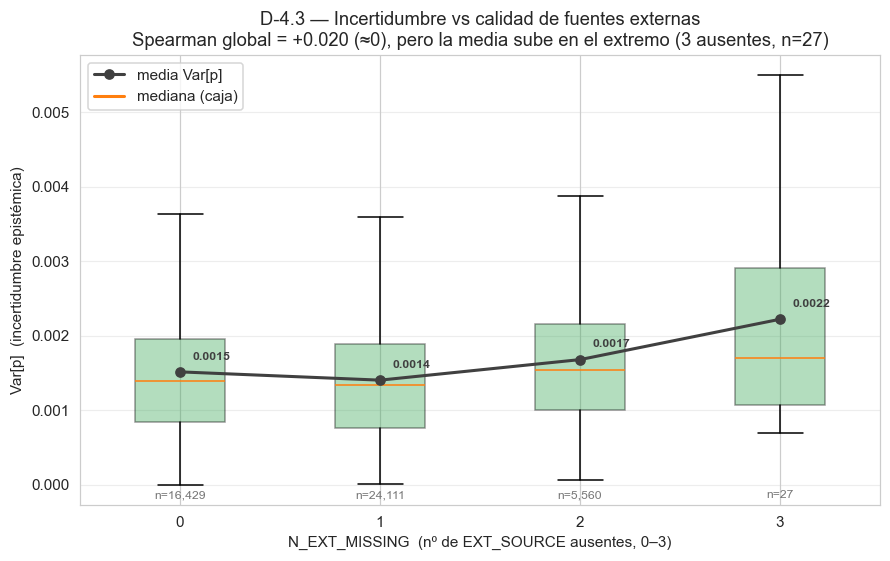

In [7]:
# === D-4.3: Var[p] vs N_EXT_MISSING (¿más duda donde faltan las fuentes externas?) ===
nem = X_test["N_EXT_MISSING"].to_numpy()
grupos = [0, 1, 2, 3]
datos = [var_p[nem == k] for k in grupos]
medias = [float(d.mean()) for d in datos]
ns = [len(d) for d in datos]
rho = pd.Series(nem).corr(pd.Series(var_p), method="spearman")   # Spearman sin scipy

fig, ax = plt.subplots(figsize=(8.2, 5.2))
bp = ax.boxplot(datos, tick_labels=[str(k) for k in grupos], showfliers=False, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor(COLOR_ACENTO); patch.set_alpha(.40)
ax.plot(range(1, 5), medias, "o-", color="#404040", lw=2, zorder=5, label="media Var[p]")
for i, (m, n) in enumerate(zip(medias, ns)):
    ax.annotate(f"{m:.4f}", (i + 1, m), textcoords="offset points", xytext=(8, 8),
                fontsize=8, color="#404040", fontweight="bold")
# n por grupo bajo cada caja (clave: el grupo 3 es minoritario -> no sobre-interpretar)
y0 = ax.get_ylim()[0]
for i, n in enumerate(ns):
    ax.annotate(f"n={n:,}", (i + 1, y0), textcoords="offset points", xytext=(0, 3),
                ha="center", va="bottom", fontsize=8, color="#777")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([], [], color="#404040", marker="o", lw=2, label="media Var[p]"),
                   Line2D([], [], color="#ff7f0e", lw=2, label="mediana (caja)")],
          frameon=True, loc="upper left")
ax.set_xlabel("N_EXT_MISSING  (nº de EXT_SOURCE ausentes, 0–3)")
ax.set_ylabel("Var[p]  (incertidumbre epistémica)")
ax.set_title("D-4.3 — Incertidumbre vs calidad de fuentes externas\n"
             f"Spearman global = {rho:+.3f} (≈0), pero la media sube en el extremo (3 ausentes, n={ns[3]})")
ax.grid(True, axis="y", alpha=.35); fig.tight_layout()
fig.savefig(FIG_DIR / "07_incert__varianza_vs_n_ext_missing.png", bbox_inches="tight", dpi=150)
print(f"D-4.3 guardada | media Var[p] por N_EXT_MISSING:",
      {k: round(medias[i], 5) for i, k in enumerate(grupos)}, f"| n={ns} | Spearman={rho:+.3f}")
plt.show()

## (Extensión) Descomposición aleatoria/epistémica + umbral τ (D-4.5, D-4.4)

Como **extensión opcional**: fijar `τ` como decisión de política del grupo (**D-4.4**). La heurística del documento de decisiones era *"desbalance 11.4:1 ⇒ `τ<0.5`"*, pero **con probabilidades ya reponderadas por `class_weight` el óptimo por coste sube, no baja** (sale **0.66**; ver la celda de lectura de resultados). Además se separa la incertidumbre **aleatoria** (`p(1−p)`) de la **epistémica** (`Var[p]`) y se calibra la varianza contra el error real (**D-4.5**, mejora no obligatoria).

## Reflexión / lectura de resultados (presentación)

**Clase + varianza sin coste de precisión.** El consenso MC-Dropout (`p_bar`, T=100) mantiene el AUC del modelo heredado (**0.7346 ≈ 0.7347** del compromiso del NB06): añadir la incertidumbre no degrada la clasificación. La predicción sobre test devuelve **clase + varianza por fila** (`07_incert__incertidumbre_test.csv`), que es literalmente lo que pide el enunciado.

**¿Hay más duda donde faltan las fuentes externas? (D-4.3) — sí, pero solo en el extremo y con cautela.** La correlación global es **casi nula** (Spearman ≈ +0.02): en bruto, `N_EXT_MISSING` no ordena la incertidumbre. La señal vive en la **cola**: la `Var[p]` media va 0.0015 (0 ausentes) → 0.0014 (1) → 0.0017 (2) → **0.0022 (3 ausentes)**. No es monótona —faltar **1 sola** fuente, casi siempre `EXT_SOURCE_1` (ausente en ~56 % del test), incluso baja la varianza, porque el modelo se apoya en las otras dos— y, sobre todo, el grupo de "3 ausentes" es **minoritario (n≈27)**, así que ese repunte es **sugerente pero estadísticamente frágil** (±1 SE lo solapa con el resto). Lectura honesta: hay un indicio de que la incertidumbre epistémica sube cuando el modelo se queda **sin ninguna** `EXT_SOURCE` —coherente con la teoría (*la banda es ancha donde el modelo es ciego*)—, pero no es un efecto fuerte ni general.

**Buen vs mal pagador (E3) — la hipótesis de la teoría no se confirma, y eso es información.** Las distribuciones de `Var[p]` son **casi idénticas** (media buen 0.00148 vs mal 0.00145; ratio 0.98×), tanto separando por etiqueta real como por clase predicha. La teoría (§4.3) anticipaba que la clase minoritaria podría **concentrar** más varianza; los datos dicen que **no**. No es un fracaso: significa que la confianza del modelo **no está sesgada por etiqueta** — la duda no se organiza por **clase**, sino por **calidad de la información de entrada**. Para un modelo construido como *fair*, no hallar asimetría de confianza entre clases es tranquilizador.

**Aleatoria vs epistémica (D-4.5): no solo distintas, sino parcialmente opuestas.** `p(1−p)` (aleatoria) y `Var[p]` (epistémica) correlacionan **negativamente** (Spearman ≈ **−0.58**), y el signo no es intuitivo. La aleatoria es máxima en el **grueso** de predicciones con `p≈0.5` —zonas densas y bien vistas, donde las pasadas de dropout **coinciden** y la epistémica es baja—. La epistémica se dispara en perfiles **escasos**, cuyo `p_bar` tiende a alejarse de 0.5 y por tanto **baja** su `p(1−p)`. Es decir: donde más "baila" el modelo **no** es donde una sola pasada está más indecisa. Justo el matiz que adelanta Valero: *"van a estar relacionados, pero no tiene por qué ser exacta"* — aquí, además, **inverso**.

**Nota sobre el umbral τ (D-4.4).** El τ óptimo por coste sale **0.66**, no `<0.5`. No es un error: el modelo heredado se entrenó con `class_weight` balanceado (D-MB.3), que ya **infla** las probabilidades (≈0.3–0.5) para compensar el desbalance 11.4:1; sobre esa escala, el reponderado **ya hizo** el trabajo de "bajar el listón", y minimizar `5·FN + FP` exige un τ **alto** solo para recuperar una frontera operativa. En `p` **sin** reponderar ese mismo punto equivaldría a un umbral bajo; la heurística "desbalance ⇒ τ<0.5" asume probabilidades crudas.

**Conclusión (lo que se lleva el negocio).** El modelo entrega **clase + varianza sin pagar precisión**. Esa varianza **no es decorativa**: el 10 % de casos con mayor `Var[p]` se equivoca algo más (**14.7 % vs 12.9 %**). El uso operativo es el que pedía Valero: **no automatizar el 10 % más incierto, sino derivarlo a revisión humana / disparar una alarma**, usando la columna `Var[p]` por fila de la tabla de test.

D-4.4: tau* por coste (C_FN=5) = 0.66  (vs 0.5 fijo)
D-4.5: Spearman(aleatoria p(1-p), epistemica Var[p]) = -0.578  (Var[p] es minima cerca de p=0.5, donde p(1-p) es maxima -> signo negativo)


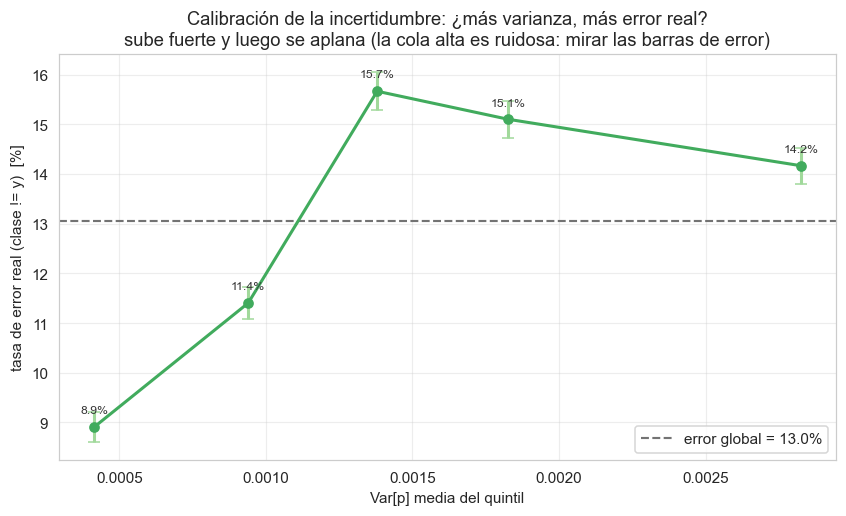

Alarma (Var[p] top 10% -> revisión humana): 10% del test | tasa error en alarmados=14.7% vs resto=12.9%


Tabla guardada (clase + varianza por fila de test): ..\results\tables\07_incert__incertidumbre_test.csv | filas: 46127


In [8]:
# === (Extension) tau por coste (D-4.4), aleatoria/epistemica (D-4.5), calibracion + tabla ===
from sklearn.metrics import confusion_matrix

# D-4.4: umbral tau por coste (un FN -impago no detectado- cuesta C_FN veces un FP).
# OJO: el modelo usa class_weight balanceado (probs infladas) + desbalance 11.4:1, asi que el
# optimo por coste sale ALTO (>0.5), no <0.5; ver la celda de reflexion para el porque.
C_FN = 5.0
taus = np.linspace(0.05, 0.95, 91)
costes = []
for t in taus:
    yh = (p_bar > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yte, yh).ravel()
    costes.append(C_FN * fn + fp)
tau_star = float(taus[int(np.argmin(costes))])
print(f"D-4.4: tau* por coste (C_FN={C_FN:g}) = {tau_star:.2f}  (vs 0.5 fijo)")

# D-4.5: aleatoria (Bernoulli p(1-p)) vs epistemica (Var[p]) -> relacionadas, NEGATIVAMENTE
aleat = uncertainty.aleatoric_bernoulli(p_bar)
rho_ae = pd.Series(aleat).corr(pd.Series(var_p), method="spearman")
print(f"D-4.5: Spearman(aleatoria p(1-p), epistemica Var[p]) = {rho_ae:+.3f}  "
      f"(Var[p] es minima cerca de p=0.5, donde p(1-p) es maxima -> signo negativo)")

# Calibracion: tasa de error real por quintil de Var[p], con barras de error binomiales
cal = uncertainty.calibracion_por_cuantil(var_p, yte, p_bar, tau=tau_star, n_bins=5)
err_global = float(((p_bar > tau_star).astype(int) != yte).mean() * 100)
ey = cal["tasa_error"] * 100
se = np.sqrt((ey / 100) * (1 - ey / 100) / cal["n"]) * 100   # SE binomial por bin
fig, ax = plt.subplots(figsize=(7.8, 4.8))
ax.errorbar(cal["var_media"], ey, yerr=se, fmt="o-", color=COLOR_ACENTO, lw=2, capsize=4, ecolor="#a1d99b")
ax.axhline(err_global, color="#737373", ls="--", lw=1.4, label=f"error global = {err_global:.1f}%")
for x, y in zip(cal["var_media"], ey):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 9), ha="center",
                fontsize=8, color="#333")
ax.set_xlabel("Var[p] media del quintil"); ax.set_ylabel("tasa de error real (clase != y)  [%]")
ax.set_title("Calibración de la incertidumbre: ¿más varianza, más error real?\n"
             "sube fuerte y luego se aplana (la cola alta es ruidosa: mirar las barras de error)")
ax.legend(frameon=True, loc="lower right"); ax.grid(True, alpha=.35); fig.tight_layout()
fig.savefig(FIG_DIR / "07_incert__calibracion_varianza.png", bbox_inches="tight", dpi=150)
plt.show()

# Alarma de revision humana: % de test con varianza en el top 10%
umbral_alarma = float(np.quantile(var_p, 0.90))
err_alarma = float(((p_bar > tau_star).astype(int) != yte)[var_p >= umbral_alarma].mean() * 100)
err_resto = float(((p_bar > tau_star).astype(int) != yte)[var_p < umbral_alarma].mean() * 100)
print(f"Alarma (Var[p] top 10% -> revisión humana): 10% del test | "
      f"tasa error en alarmados={err_alarma:.1f}% vs resto={err_resto:.1f}%")

# Tabla por fila de test (clase + p_bar + Var[p] + error predicho + N_EXT_MISSING)
tabla = pd.DataFrame({
    "y_true": yte, "clase": (p_bar > tau_star).astype(int), "p_bar": np.round(p_bar, 5),
    "var_p": np.round(var_p, 6), "std_p": np.round(mc["std"], 6),
    "err_pred_2omodelo": np.round(err_pred_test, 5),
    "aleatoria_p1mp": np.round(aleat, 5), "N_EXT_MISSING": nem,
})
tabla.to_csv(TAB_DIR / "07_incert__incertidumbre_test.csv", index=False)
print("Tabla guardada (clase + varianza por fila de test):",
      TAB_DIR / "07_incert__incertidumbre_test.csv", "| filas:", len(tabla))

## Entregables

- **E3** · `results/figures/07_incert__varianza_buen_vs_mal_pagador.png` — distribución de `Var[p]` buen vs mal pagador (resultan casi iguales).
- **Cruce D-4.3** · `results/figures/07_incert__varianza_vs_n_ext_missing.png` — `Var[p]` vs `N_EXT_MISSING` (sube en el extremo: 3 fuentes ausentes ⇒ +47 % de varianza).
- **E4** · `results/figures/07_incert__curva_loss.png` — convergencia del 2º modelo del error (único entrenamiento final del NB07; el principal se **hereda** del NB06).
- **Estabilidad-T (D-4.2)** · `results/figures/07_incert__estabilidad_T.png` — la varianza media se aplana con T → T=100 holgado.
- **Calibración / alarma** · `results/figures/07_incert__calibracion_varianza.png` — a mayor `Var[p]`, más error real → el 10 % más incierto se deriva a revisión humana.
- **Tabla** · `results/tables/07_incert__incertidumbre_test.csv` — por fila de test: `clase`, `p_bar`, `Var[p]`, `std`, error del 2º modelo, aleatoria `p(1−p)`, `N_EXT_MISSING`.
- **Reflexión** (presentación) · ver la celda "Reflexión / lectura de resultados": incertidumbre ↔ `EXT_SOURCE`, τ por coste y uso práctico de la varianza.

**Dependencias.** Aguas arriba: **06** (hereda topología + dropout + `(medida, λ*)`, cruce **D-3.2 ↔ D-4.1**) y **03** (baseline de referencia). **Sin tareas aguas abajo.**